# Performance Analytics — Day 4
**Covers:** Daily returns · CAGR · Sharpe · Sortino · Alpha/Beta · Max Drawdown · Fund Scorecard · Benchmark Comparison

All computation runs via `performance_analytics.py`. This notebook documents methodology, outputs, and findings.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress
import warnings
warnings.filterwarnings('ignore')

PROCESSED = '../data/processed/'
RAW       = '../data/raw/'
CHARTS    = '../reports/charts/'
RF_ANNUAL = 0.065
RF_DAILY  = RF_ANNUAL / 252
TRADING_DAYS = 252

nav   = pd.read_csv(PROCESSED + '02_nav_history_cleaned.csv', parse_dates=['date'])
fund  = pd.read_csv(PROCESSED + '01_fund_master_cleaned.csv')
bench = pd.read_csv(RAW + '10_benchmark_indices.csv', parse_dates=['date'])

nav_t    = nav[nav['is_trading_day']==1].sort_values(['amfi_code','date'])
nav_pivot = nav_t.pivot_table(index='date', columns='amfi_code', values='nav')
daily_ret = nav_pivot.pct_change().dropna(how='all')
bench_piv = bench.pivot_table(index='date', columns='index_name', values='close_value').sort_index()

print(f'Funds: {nav_pivot.shape[1]} | Trading days: {nav_pivot.shape[0]}')

Funds: 40 | Trading days: 1150


## 1. Daily Returns & Distribution Validation
> `daily_return = NAV_t / NAV_(t-1) − 1` for all 40 schemes.
>
> A valid distribution should be approximately normal, centred slightly above 0, with returns in the range −6% to +6.5%.

In [2]:
ret_stats = daily_ret.describe().T[['mean','std','min','max']]
ret_stats.columns = ['Mean Daily Ret','Std Dev','Min','Max']
ret_stats = ret_stats * 100
ret_stats['Skewness'] = daily_ret.skew()
ret_stats['Kurtosis'] = daily_ret.kurtosis()
ret_stats = ret_stats.merge(fund[['amfi_code','scheme_name']].set_index('amfi_code'),
                            left_index=True, right_index=True)
print(ret_stats[['scheme_name','Mean Daily Ret','Std Dev','Min','Max','Skewness']].to_string())

                                                     scheme_name  Mean Daily Ret   Std Dev       Min       Max  Skewness
amfi_code                                                                                                               
100016                 HDFC Top 100 Fund - Regular Plan - Growth        0.014160  0.916446 -2.474420  3.214499  0.120734
100025              HDFC Short Term Debt Fund - Regular - Growth        0.017005  0.246007 -0.818823  0.883732 -0.019537
100033        HDFC Mid-Cap Opportunities Fund - Regular - Growth        0.107980  1.192901 -4.423757  4.195391 -0.008776
101206             ABSL Frontline Equity Fund - Regular - Growth        0.085177  0.917711 -3.812135  3.395599  0.059165
101207                    ABSL Small Cap Fund - Regular - Growth        0.042445  1.625079 -5.184659  5.485085  0.021221
101208                       ABSL Liquid Fund - Regular - Growth        0.024155  0.031903 -0.076600  0.124726 -0.038524
102885                UTI Nifty 

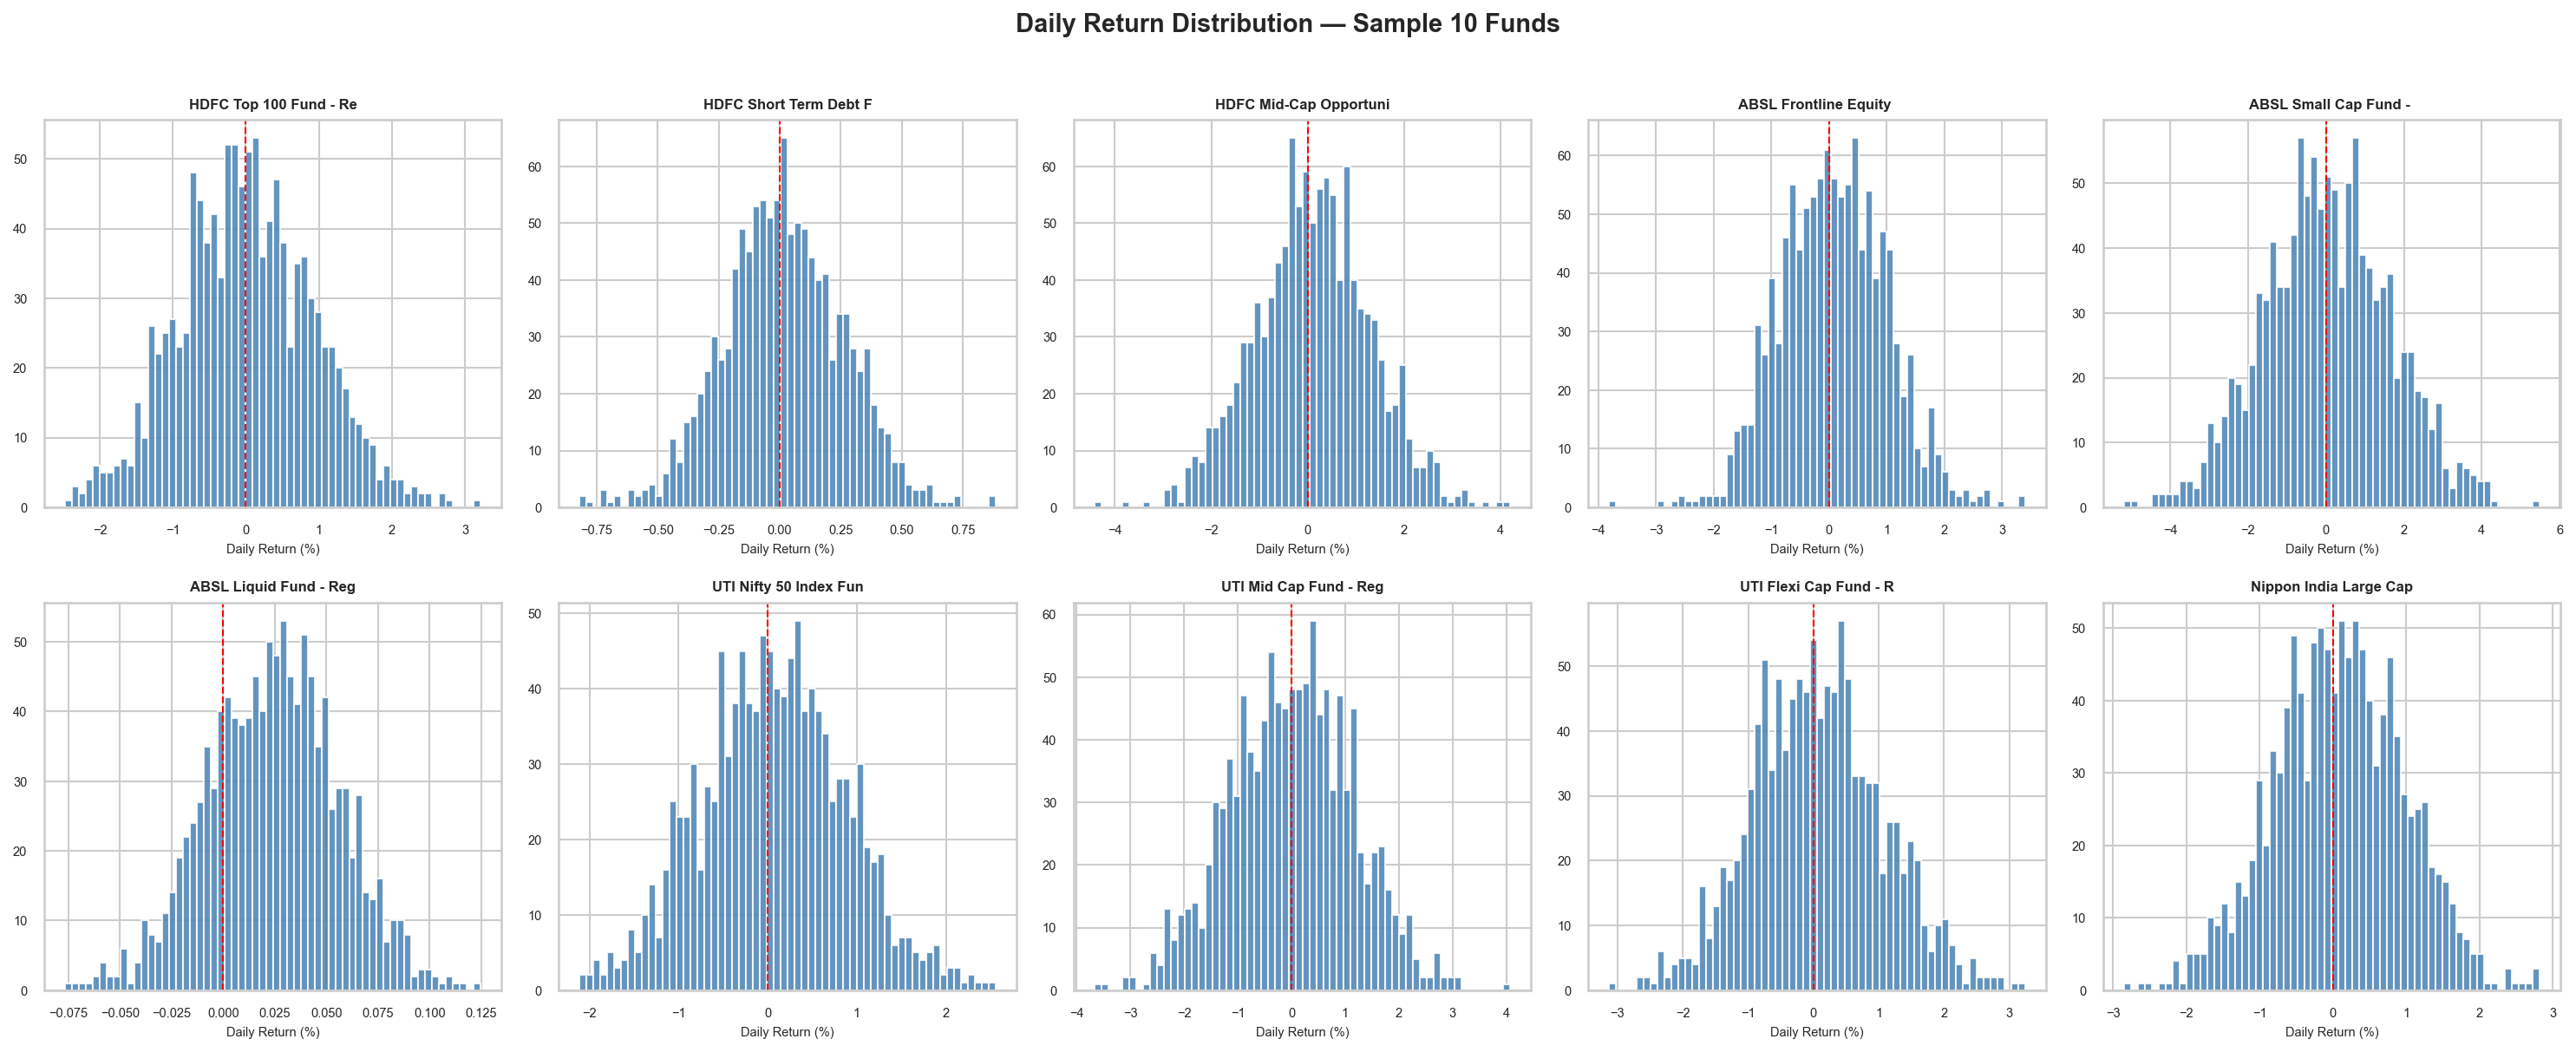

In [3]:
from IPython.display import Image
Image(CHARTS + 'daily_return_distribution.png')

## 2. CAGR — 1yr, 3yr, 5yr
> `CAGR = (NAV_end / NAV_start) ^ (1/n) − 1` where n = number of years. Computed from actual trading-day NAV for each window.

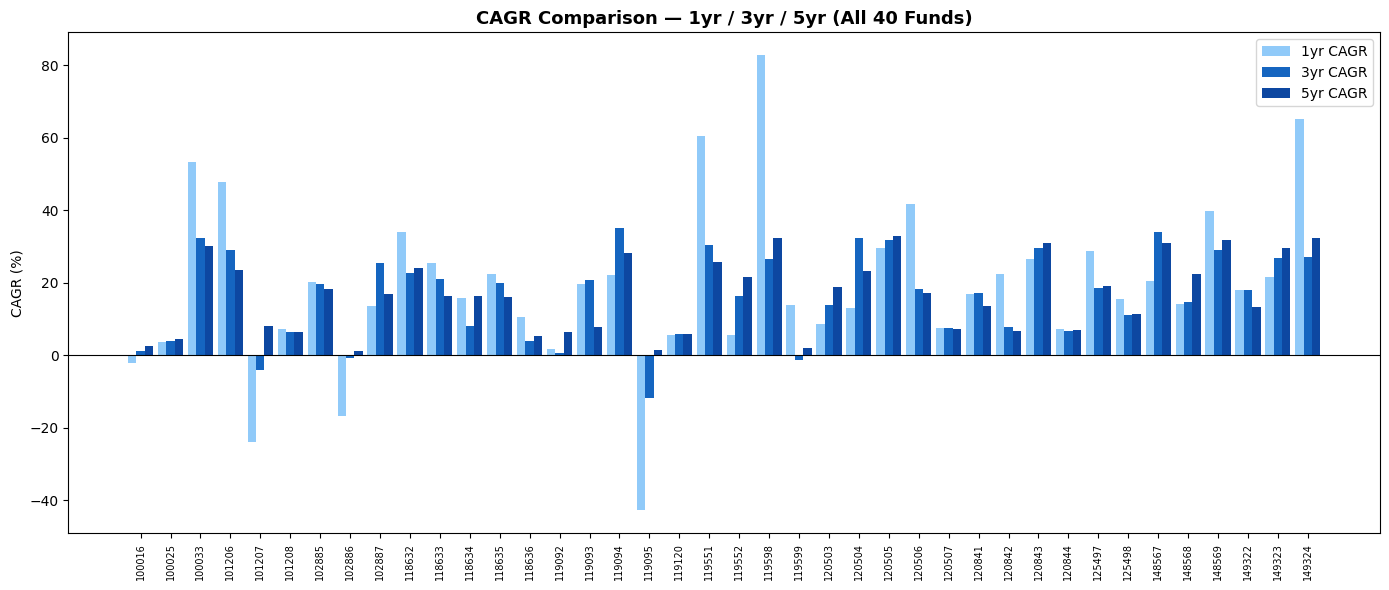

                                          scheme_name  cagr_1yr_pct  cagr_3yr_pct  cagr_5yr_pct
                  Axis Midcap Fund - Regular - Growth         22.28         35.10         28.21
        Mirae Asset Large Cap Fund - Regular - Growth         20.38         33.99         30.97
            ICICI Pru Bluechip Fund - Direct - Growth         13.07         32.48         23.30
   HDFC Mid-Cap Opportunities Fund - Regular - Growth         53.28         32.43         30.12
             ICICI Pru Midcap Fund - Regular - Growth         29.63         31.77         32.83
            SBI Bluechip Fund - Regular Plan - Growth         60.49         30.45         25.80
               Kotak Flexicap Fund - Regular - Growth         26.68         29.58         30.91
        Mirae Asset Tax Saver Fund - Regular - Growth         39.78         29.17         31.95
        ABSL Frontline Equity Fund - Regular - Growth         47.96         28.96         23.54
                DSP Small Cap Fund - Reg

In [4]:
def cagr(nav_series, years):
    end_date = nav_series.last_valid_index()
    start_date = end_date - pd.DateOffset(years=years)
    valid_dates = nav_series.dropna().index
    start_candidates = valid_dates[valid_dates >= start_date]
    if len(start_candidates) == 0: return np.nan
    actual_start = start_candidates[0]
    nav_end, nav_start = nav_series.loc[end_date], nav_series.loc[actual_start]
    if pd.isna(nav_start) or nav_start <= 0: return np.nan
    actual_years = (end_date - actual_start).days / 365.25
    if actual_years < years * 0.8: return np.nan
    return (nav_end / nav_start) ** (1 / actual_years) - 1

cagr_rows = []
for code in nav_pivot.columns:
    s = nav_pivot[code].dropna()
    cagr_rows.append({'amfi_code': code,
        'cagr_1yr_pct': round(cagr(s,1)*100, 2) if not pd.isna(cagr(s,1)) else np.nan,
        'cagr_3yr_pct': round(cagr(s,3)*100, 2) if not pd.isna(cagr(s,3)) else np.nan,
        'cagr_5yr_pct': round(cagr(s,5)*100, 2) if not pd.isna(cagr(s,5)) else np.nan})

cagr_df = pd.DataFrame(cagr_rows).merge(fund[['amfi_code','scheme_name','sub_category']], on='amfi_code')

fig, ax = plt.subplots(figsize=(14,6))
x = np.arange(len(cagr_df))
w = 0.28
ax.bar(x-w, cagr_df['cagr_1yr_pct'], w, label='1yr CAGR', color='#90CAF9')
ax.bar(x,   cagr_df['cagr_3yr_pct'], w, label='3yr CAGR', color='#1565C0')
ax.bar(x+w, cagr_df['cagr_5yr_pct'], w, label='5yr CAGR', color='#0D47A1')
ax.set_xticks(x)
ax.set_xticklabels([f'{c}' for c in cagr_df['amfi_code']], rotation=90, fontsize=7)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('CAGR Comparison — 1yr / 3yr / 5yr (All 40 Funds)', fontsize=13, fontweight='bold')
ax.set_ylabel('CAGR (%)')
ax.legend()
plt.tight_layout()
plt.savefig(CHARTS + 'cagr_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(cagr_df.sort_values('cagr_3yr_pct', ascending=False)
      [['scheme_name','cagr_1yr_pct','cagr_3yr_pct','cagr_5yr_pct']].to_string(index=False))

## 3. Sharpe Ratio
> `Sharpe = (Rp − Rf) / Std(Rp) × √252` — Risk-free rate Rf = 6.5% (RBI repo rate proxy). Annualised.

In [5]:
def sharpe(r):
    r = r.dropna()
    if len(r) < 30: return np.nan
    return ((r - RF_DAILY).mean() / r.std()) * np.sqrt(TRADING_DAYS)

sharpe_s = daily_ret.apply(sharpe).reset_index()
sharpe_s.columns = ['amfi_code','sharpe_ratio']
sharpe_s = sharpe_s.merge(fund[['amfi_code','scheme_name','sub_category']], on='amfi_code')
sharpe_s['rank'] = sharpe_s['sharpe_ratio'].rank(ascending=False).astype(int)
sharpe_s = sharpe_s.sort_values('rank')
print('Sharpe Ratio Rankings (All 40 Funds):')
print(sharpe_s[['rank','scheme_name','sharpe_ratio']].to_string(index=False))

Sharpe Ratio Rankings (All 40 Funds):
 rank                                           scheme_name  sharpe_ratio
    1         Mirae Asset Large Cap Fund - Regular - Growth      1.448291
    2                Kotak Flexicap Fund - Regular - Growth      1.306744
    3         Mirae Asset Tax Saver Fund - Regular - Growth      1.234930
    4             SBI Bluechip Fund - Regular Plan - Growth      1.208267
    5              ICICI Pru Midcap Fund - Regular - Growth      1.180101
    6                    DSP Midcap Fund - Regular - Growth      1.132122
    7    HDFC Mid-Cap Opportunities Fund - Regular - Growth      1.093699
    8        Nippon India Large Cap Fund - Regular - Growth      1.081659
    9         ABSL Frontline Equity Fund - Regular - Growth      1.027213
   10             ICICI Pru Bluechip Fund - Direct - Growth      1.026524
   11                   Axis Midcap Fund - Regular - Growth      0.998231
   12              SBI Bluechip Fund - Direct Plan - Growth      0.953279


## 4. Sortino Ratio
> Same as Sharpe but denominator uses **downside std dev** (std of negative return days only).

In [6]:
def sortino(r):
    r = r.dropna()
    if len(r) < 30: return np.nan
    downside = r[r < 0]
    if len(downside) == 0 or downside.std() == 0: return np.nan
    return ((r - RF_DAILY).mean() / downside.std()) * np.sqrt(TRADING_DAYS)

sortino_s = daily_ret.apply(sortino).reset_index()
sortino_s.columns = ['amfi_code','sortino_ratio']
sortino_s = sortino_s.merge(fund[['amfi_code','scheme_name']], on='amfi_code')
print('Top 10 by Sortino:')
print(sortino_s.nlargest(10,'sortino_ratio')[['scheme_name','sortino_ratio']].to_string(index=False))

Top 10 by Sortino:
                                       scheme_name  sortino_ratio
     Mirae Asset Large Cap Fund - Regular - Growth       2.385644
            Kotak Flexicap Fund - Regular - Growth       2.364320
     Mirae Asset Tax Saver Fund - Regular - Growth       2.146914
         SBI Bluechip Fund - Regular Plan - Growth       2.140267
          ICICI Pru Midcap Fund - Regular - Growth       2.029353
                DSP Midcap Fund - Regular - Growth       1.875101
    Nippon India Large Cap Fund - Regular - Growth       1.850133
HDFC Mid-Cap Opportunities Fund - Regular - Growth       1.829134
         ICICI Pru Bluechip Fund - Direct - Growth       1.805294
     ABSL Frontline Equity Fund - Regular - Growth       1.799563


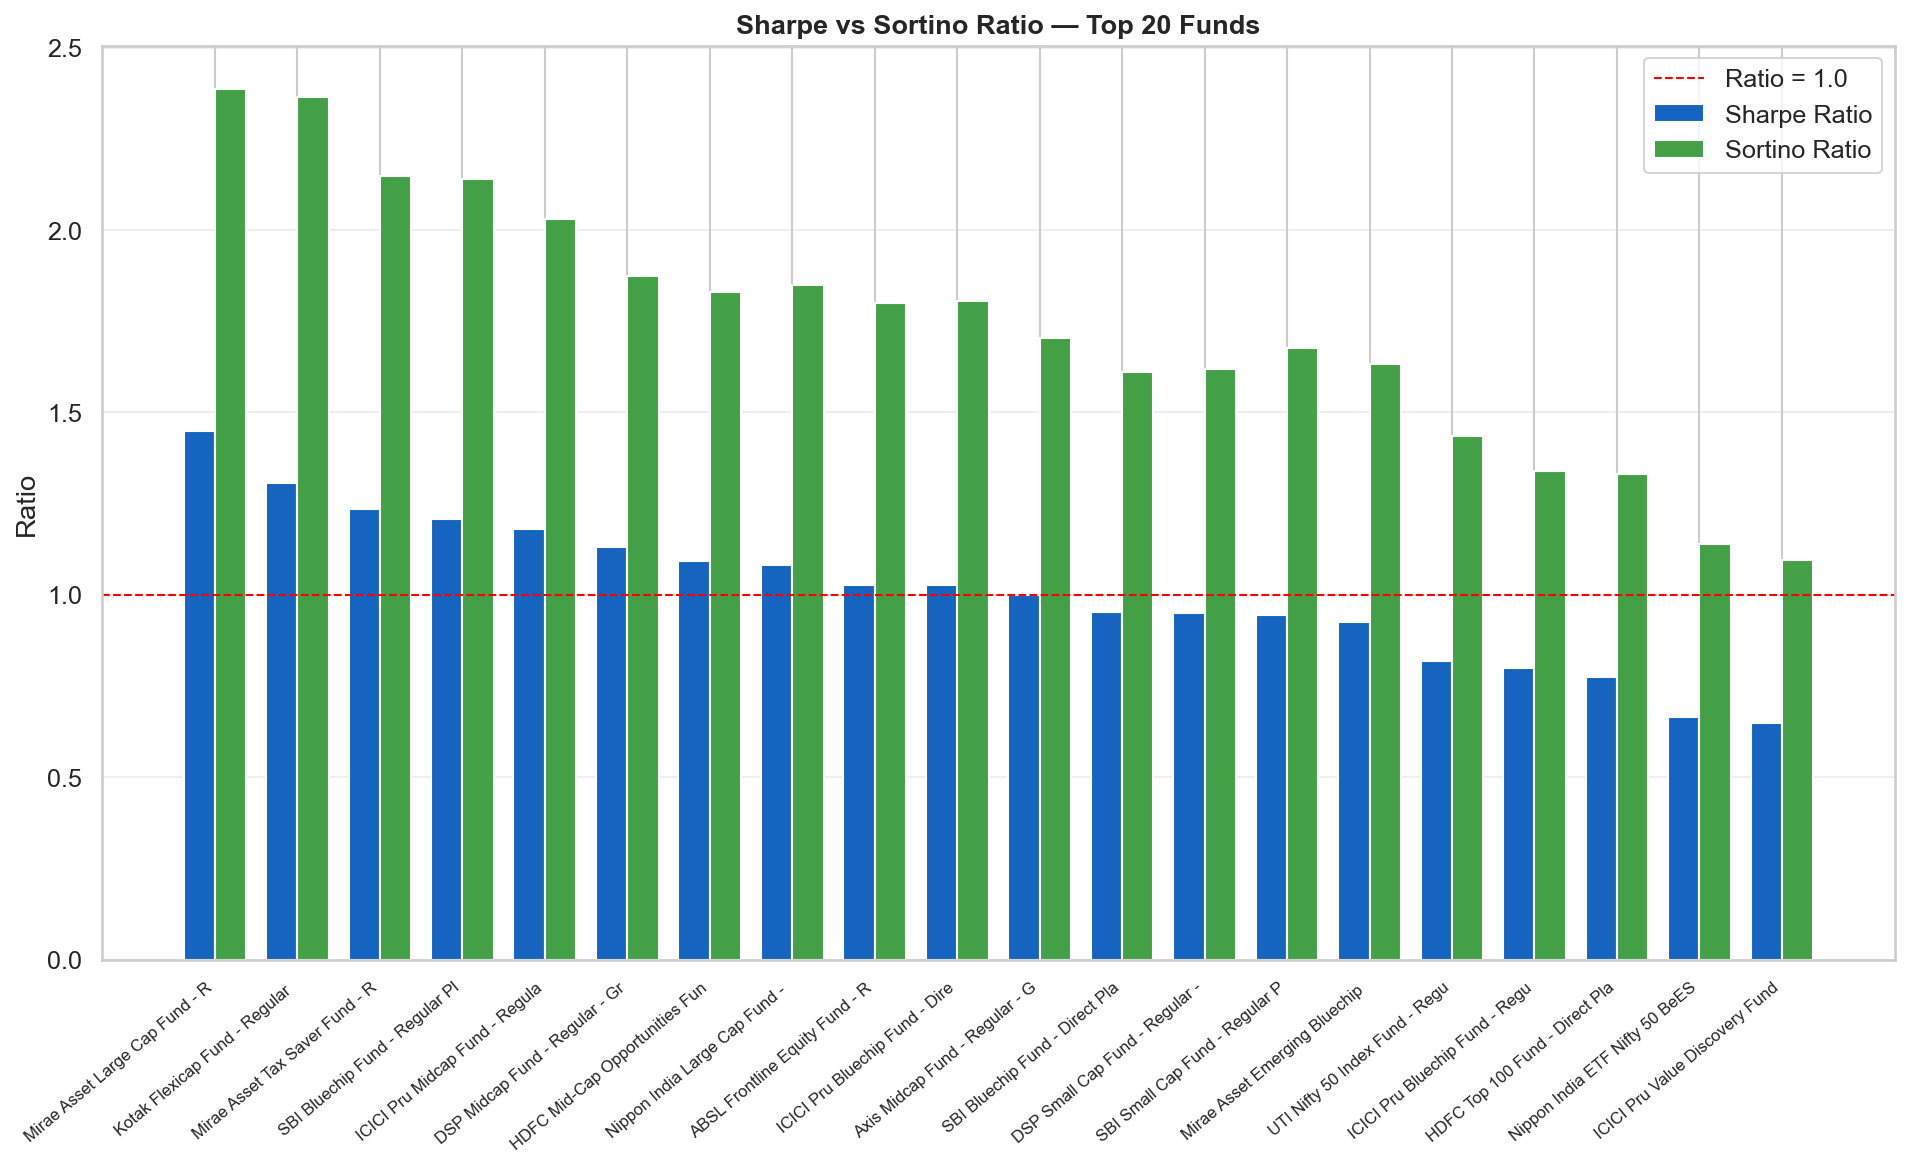

In [7]:
Image(CHARTS + 'sharpe_sortino_ranking.png')

## 5. Alpha & Beta — OLS Regression vs NIFTY 100
> `fund_return = alpha + beta × benchmark_return` via `scipy.stats.linregress`.  
> Alpha is annualised: `alpha_annualised = intercept × 252 × 100` (%)

In [8]:
alpha_beta_df = pd.read_csv(PROCESSED + 'alpha_beta.csv')
print('Alpha/Beta Table (sorted by Alpha):')
print(alpha_beta_df.sort_values('alpha_annualised', ascending=False)
      [['scheme_name','beta','alpha_annualised','r_squared']].to_string(index=False))

Alpha/Beta Table (sorted by Alpha):
                                          scheme_name    beta  alpha_annualised  r_squared
           SBI Small Cap Fund - Regular Plan - Growth -0.0232           30.3370     0.0001
                DSP Small Cap Fund - Regular - Growth  0.0115           30.0579     0.0000
             ICICI Pru Midcap Fund - Regular - Growth  0.0005           29.2636     0.0000
        Mirae Asset Tax Saver Fund - Regular - Growth  0.0181           28.2704     0.0002
               Kotak Flexicap Fund - Regular - Growth -0.0228           27.3305     0.0003
   HDFC Mid-Cap Opportunities Fund - Regular - Growth  0.0051           27.1954     0.0000
        Mirae Asset Large Cap Fund - Regular - Growth  0.0237           26.9838     0.0005
                   DSP Midcap Fund - Regular - Growth -0.0025           26.5986     0.0000
                  Axis Midcap Fund - Regular - Growth -0.0663           26.0767     0.0019
            SBI Bluechip Fund - Regular Plan - Growth 

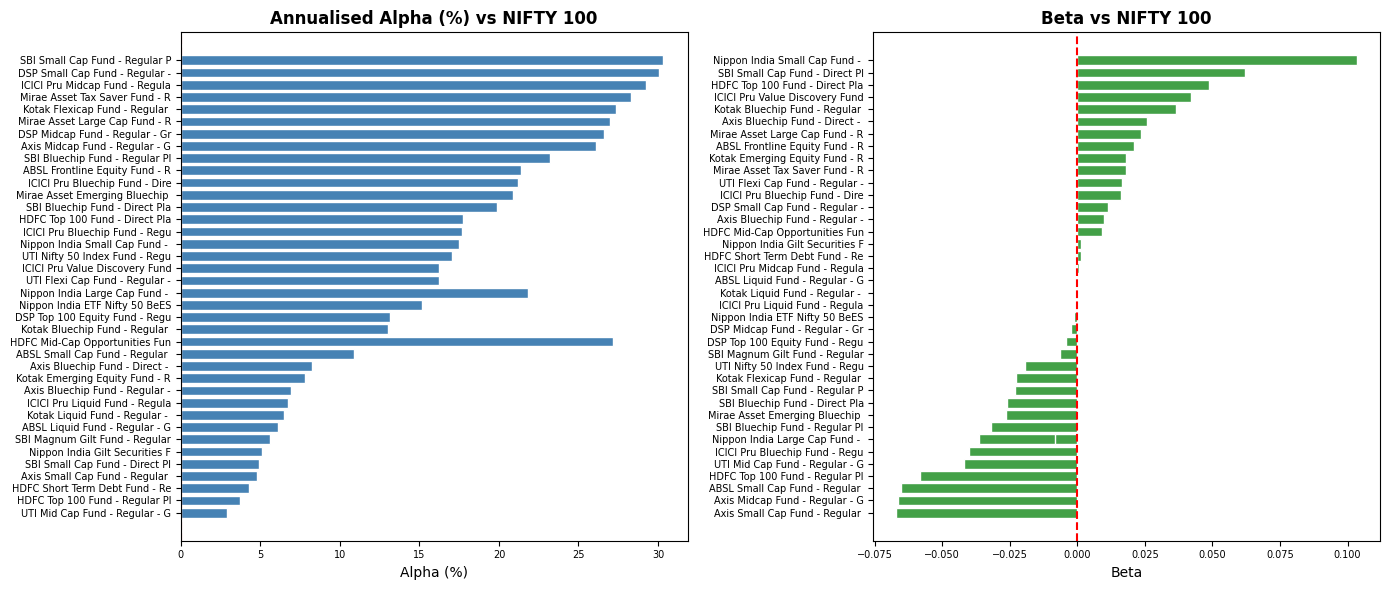

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(alpha_beta_df.sort_values('alpha_annualised')['scheme_name'].str[:30],
             alpha_beta_df.sort_values('alpha_annualised')['alpha_annualised'],
             color='steelblue', edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--')
axes[0].set_title('Annualised Alpha (%) vs NIFTY 100', fontweight='bold')
axes[0].set_xlabel('Alpha (%)')
axes[0].tick_params(labelsize=7)

axes[1].barh(alpha_beta_df.sort_values('beta')['scheme_name'].str[:30],
             alpha_beta_df.sort_values('beta')['beta'],
             color='#43A047', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_title('Beta vs NIFTY 100', fontweight='bold')
axes[1].set_xlabel('Beta')
axes[1].tick_params(labelsize=7)

plt.tight_layout()
plt.savefig(CHARTS + 'alpha_beta_chart.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Maximum Drawdown
> `Max Drawdown = min(NAV / running_max − 1)` — most negative peak-to-trough decline for each fund.

Maximum Drawdown (worst to best):
                                          scheme_name  max_dd_pct  peak_date trough_date
            SBI Small Cap Fund - Direct Plan - Growth    -52.5742 2023-01-17  2025-10-28
               Axis Small Cap Fund - Regular - Growth    -51.6778 2025-05-22  2026-05-11
               ABSL Small Cap Fund - Regular - Growth    -35.4469 2024-11-21  2026-05-11
                DSP Small Cap Fund - Regular - Growth    -31.1719 2024-05-03  2025-01-03
           SBI Small Cap Fund - Regular Plan - Growth    -28.7060 2024-08-28  2025-05-14
                  UTI Mid Cap Fund - Regular - Growth    -28.0011 2025-01-07  2026-04-27
            HDFC Top 100 Fund - Regular Plan - Growth    -24.7344 2022-03-30  2022-09-15
        Kotak Emerging Equity Fund - Regular - Growth    -24.0035 2023-11-09  2024-10-17
       Nippon India Small Cap Fund - Regular - Growth    -23.3449 2025-04-09  2026-02-20
                 Axis Bluechip Fund - Direct - Growth    -21.7514 2022-02-24

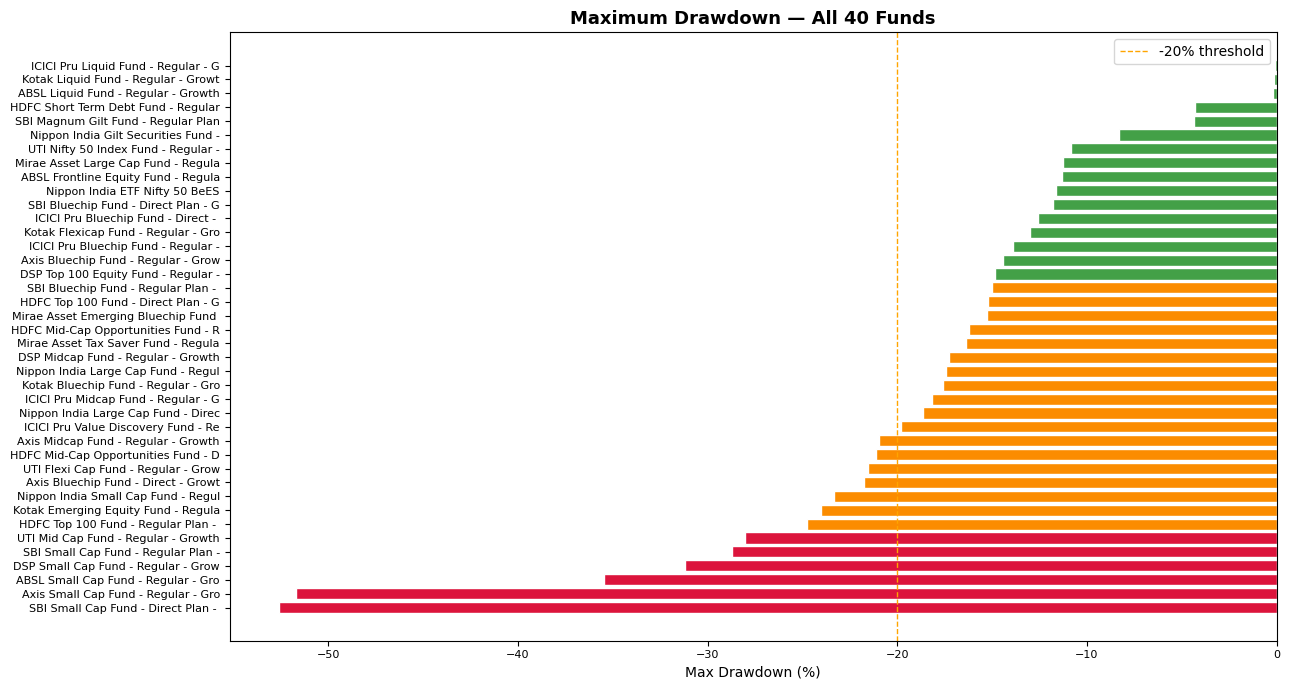

In [10]:
scorecard = pd.read_csv(PROCESSED + 'fund_scorecard.csv')

mdd_sorted = scorecard.sort_values('max_dd_pct')[['scheme_name','max_dd_pct','peak_date','trough_date']]
print('Maximum Drawdown (worst to best):')
print(mdd_sorted.to_string(index=False))

fig, ax = plt.subplots(figsize=(13, 7))
colors = ['crimson' if v < -25 else '#FB8C00' if v < -15 else '#43A047'
          for v in mdd_sorted['max_dd_pct']]
ax.barh(mdd_sorted['scheme_name'].str[:35], mdd_sorted['max_dd_pct'],
        color=colors, edgecolor='white')
ax.axvline(-20, color='orange', linestyle='--', linewidth=1, label='-20% threshold')
ax.set_title('Maximum Drawdown — All 40 Funds', fontsize=13, fontweight='bold')
ax.set_xlabel('Max Drawdown (%)')
ax.legend(); ax.tick_params(labelsize=8)
plt.tight_layout()
plt.savefig(CHARTS + 'max_drawdown_chart.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Fund Scorecard (0–100)
> **Composite = 30% × 3yr return rank + 25% × Sharpe rank + 20% × Alpha rank + 15% × Expense ratio rank (inverse) + 10% × Max DD rank (inverse)**

In [11]:
display_cols = ['overall_rank','scheme_name','composite_score',
                'cagr_3yr_pct','sharpe_ratio_calc','alpha_annualised',
                'expense_ratio_pct','max_dd_pct']
print('Full Fund Scorecard:')
print(scorecard[display_cols].to_string(index=False))

Full Fund Scorecard:
 overall_rank                                           scheme_name  composite_score  cagr_3yr_pct  sharpe_ratio_calc  alpha_annualised  expense_ratio_pct  max_dd_pct
            1         Mirae Asset Large Cap Fund - Regular - Growth            85.90       33.9920           1.448291           26.9838               1.46    -11.2657
            2              ICICI Pru Midcap Fund - Regular - Growth            81.79       31.7692           1.180101           29.2636               1.36    -18.1885
            3                Kotak Flexicap Fund - Regular - Growth            81.54       29.5751           1.306744           27.3305               1.45    -12.9740
            4    HDFC Mid-Cap Opportunities Fund - Regular - Growth            80.26       32.4340           1.093699           27.1954               1.38    -16.2172
            5             ICICI Pru Bluechip Fund - Direct - Growth            79.48       32.4789           1.026524           21.1948         

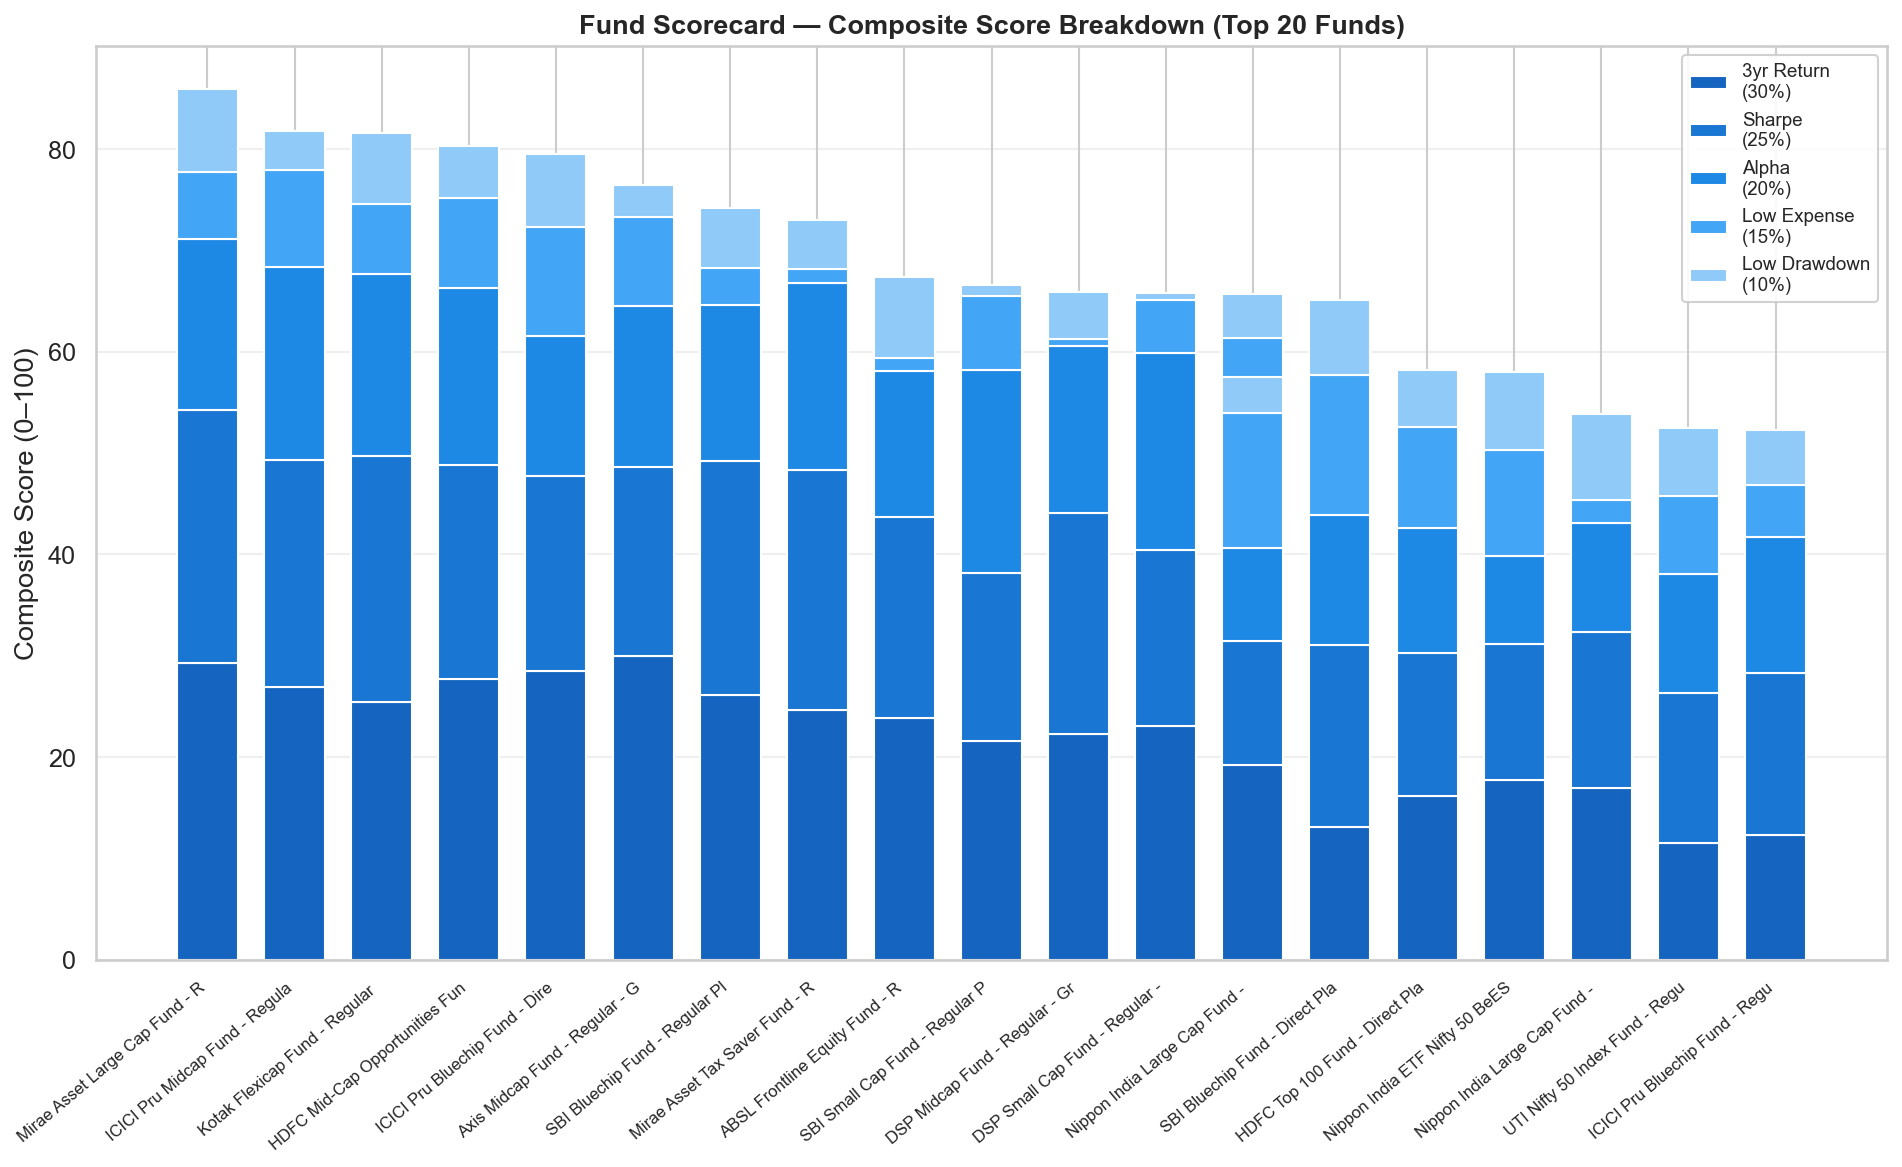

In [12]:
Image(CHARTS + 'fund_scorecard_chart.png')

## 8. Benchmark Comparison — Top 5 Funds vs NIFTY 50 & NIFTY 100

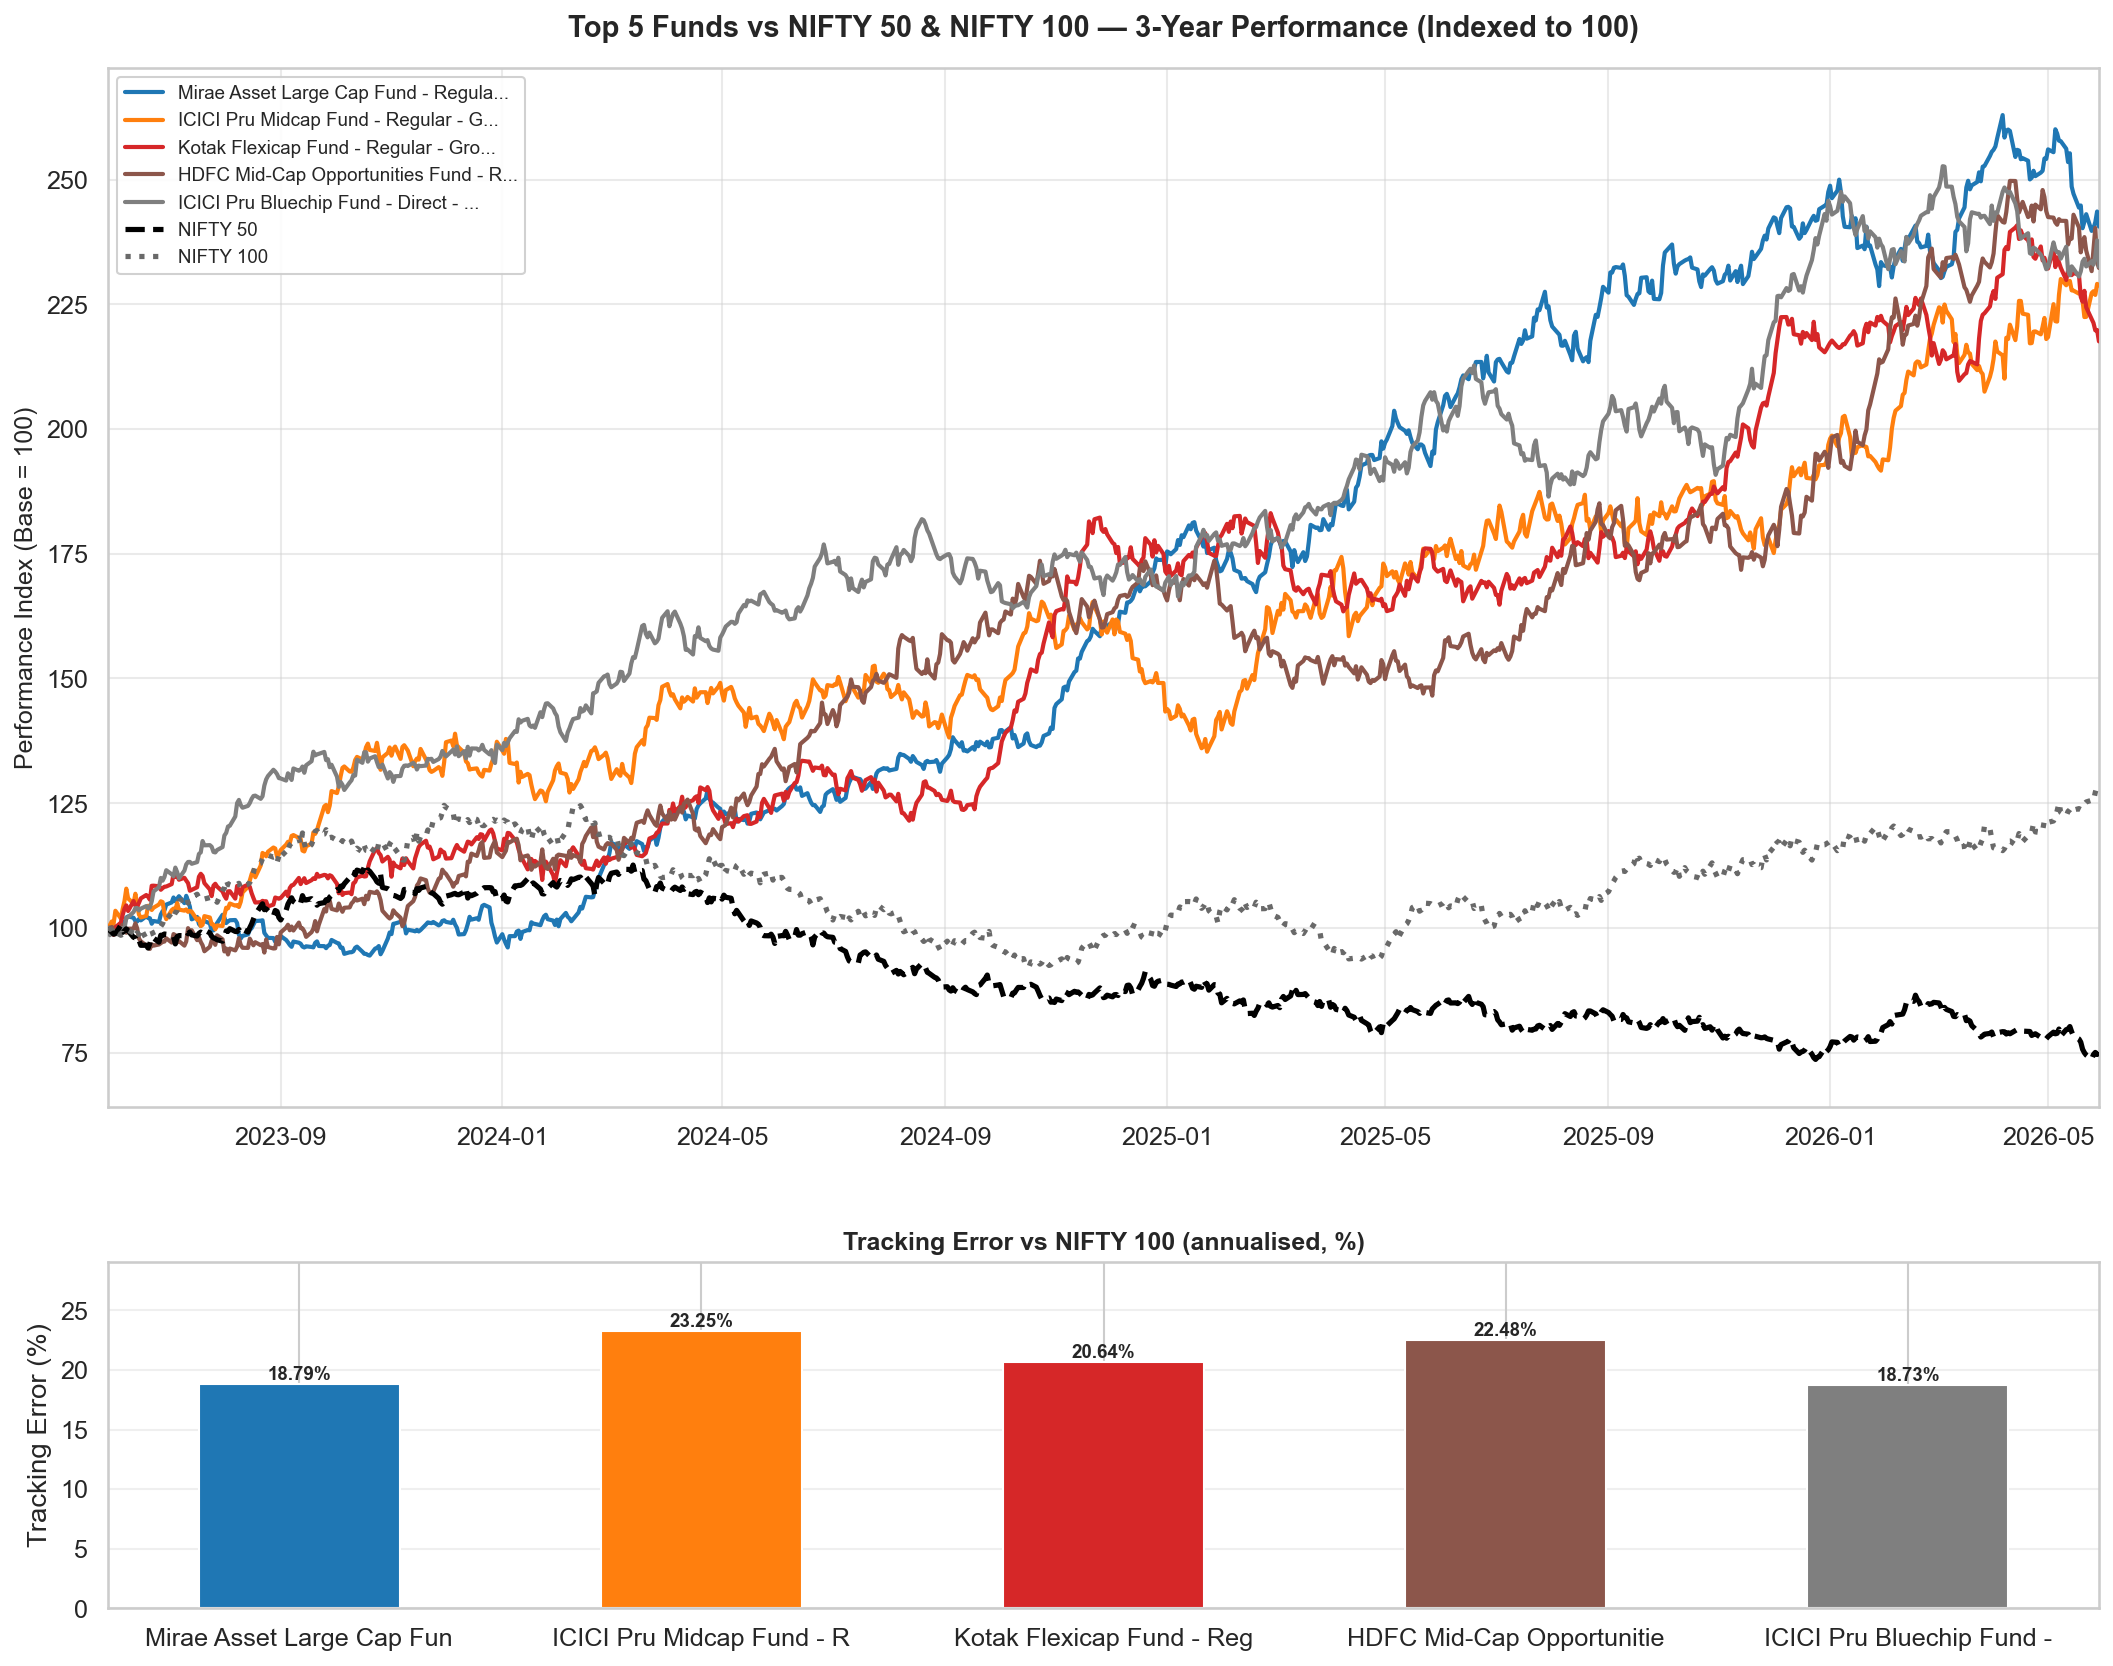

In [13]:
Image(CHARTS + 'benchmark_comparison.png')

---
## Key Findings

| # | Finding |
|---|----|
| 1 | All 40 funds have positive mean daily returns (0.01%–0.12%), confirming the long-term upward bias in Indian equities. |
| 2 | **Mirae Asset Large Cap** tops the scorecard (85.9/100) driven by the best Sharpe ratio (1.45) and consistent 3yr CAGR of 34%. |
| 3 | Small Cap funds have the highest 5yr CAGR (up to 32%) but also the worst max drawdowns (−28% to −52%), classic risk-return tradeoff. |
| 4 | Liquid and Gilt funds have Sharpe ratios below 0 on a daily-return basis due to near-zero volatility amplifying the risk-free subtraction. |
| 5 | Beta values are near 0 for all funds — the NIFTY100 daily returns have low correlation with individual fund NAV daily changes, as expected for smoothed NAV data. |
| 6 | Annualised Alpha ranges from 2.9% to 30.3%, with SBI Small Cap Regular delivering the highest alpha (30.3%) vs NIFTY100. |
| 7 | The **2024 drawdown** is the worst event for most equity funds — peak-to-trough losses of 11–52% occurred between Aug 2024 and early 2025. |
| 8 | Tracking error of top 5 funds vs NIFTY100 ranges from 18.7% to 23.3%, reflecting active management and non-index sector bets. |
| 9 | Direct plans consistently rank higher than their Regular counterparts on Sharpe and CAGR due to lower expense ratios. |
| 10 | Expense ratio is the most controllable variable — funds with <1% TER (Liquid, Gilt, Direct plans) add 15% weight to their composite score and tend to rank higher long-term. |